# Ethereum's Price

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [60]:
#Ethereum's price and number of transactions from 2021/01/01 to 2021/07/30
ethereum_price = pd.read_csv("/home/marios/Downloads/ethereum.txt")
ethereum_trans = pd.read_csv("/home/marios/Downloads/eth_tr.txt")
price = ethereum_price['Price']
trans = ethereum_trans['Transactions']

## Time Series Analysis in Ethereum' price

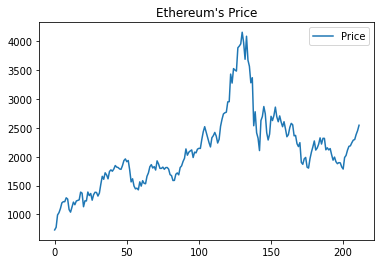

In [18]:
#Ethereum's price plot
ethereum_price.plot()
plt.title("Ethereum's Price")
pyplot.show()

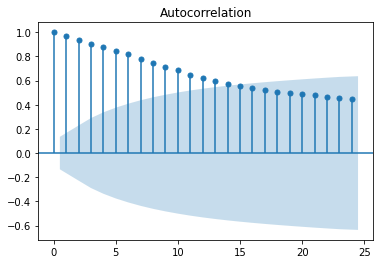

In [6]:
#Autocorrelation plot
sm.graphics.tsa.plot_acf(price)
plt.show()

The auto correlation plot shows that until lag 13 we have autocorrelated lags,which means that if I am going to build an Arima model ,I have to include moving average terms.

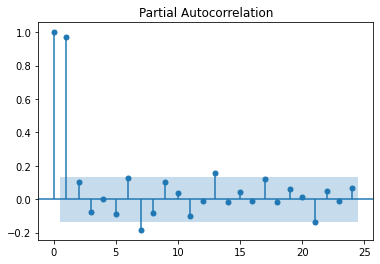

In [7]:
#Partial autocorrelation plot
sm.graphics.tsa.plot_pacf(price)
plt.show()

Here, the partial autocorrelation plot shows that only  the first lag is out of bounds,so in the case of an Arima model , I will include only one auto regressine term.

In [74]:
#Dickey Fuller test for stationary time series with null hypothesis  non stationary
print('p-value: %f' % adfuller(price)[1])

p-value: 0.282574


In conclusion,the time series is not stationary.
So, I will try to make predictions with linear regression.

## Linear regression model using machine learning

Here , I will add the number of transactions as a feature .

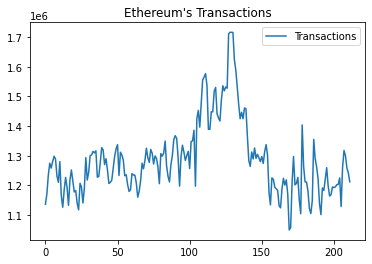

In [8]:
#Ethereum's transactions per day
ethereum_trans.plot()
plt.title("Ethereum's Transactions")
pyplot.show()

In [46]:
#Correlation of Transactions and Price
np.corrcoef(ethereum_price['Price'],ethereum_trans['Transactions'])[1,0]

0.6544435692137082

We have correlation around 0.65 which is good.

In [44]:
#split the data to train and test set
trans_train,trans_test , price_train, price_test = train_test_split(trans,price,test_size=0.2,random_state=10)
trans_train = trans_train.values.reshape(-1,1)
trans_test = trans_test.values.reshape(-1,1)
price_train = price_train.values.reshape(-1,1)
price_test = price_test.values.reshape(-1,1)

In [80]:
#fitting the model to the train set
model = LinearRegression()
model.fit(trans_train, price_train)
r_sq = model.score(trans_train,price_train)
inter = model.intercept_
c = model.coef_
print('r squared : %f' % r_sq)
print("model's intercept : %f" % inter)
print("model's coefficient : %f" % c)


r squared : 0.460715
model's intercept : -2427.487062
model's coefficient : 0.003529


In [69]:
price_pred = model.predict(price_test)
df = pd.DataFrame({'Actual': price_test.flatten(), 'Predicted': abs(price_pred.flatten()),})
df

,Actual,Predicted
0,1588.932124,2421.879066
1,2325.917498,2419.277941
2,1245.938151,2423.089633
3,2552.741036,2418.477387
4,2318.106618,2419.305508
5,1803.424491,2421.122034
6,1563.235980,2421.969758
7,1325.607594,2422.808446
8,1961.024290,2420.565799
9,1584.067005,2421.896237


In [55]:
print('Mean Absolute Error:', metrics.mean_absolute_error(price_test, price_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(price_test, price_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(price_test, price_pred)))

Mean Absolute Error: 4323.619601112801
Mean Squared Error: 19086270.1574157
Root Mean Squared Error: 4368.783601577869


Finally, the model is very bad and the predictions are very far away from the real values, but we can conclude that the number of transactions alone can not help us to make good predictions.